## Aprendizaje batch

Sabemos que el método de gradiente descendente es un método de estimación de parámetros para los modelos, eso se logra minimizando una función de costo o perdida o maximizando un score. 

### Ejemplo: regresión lineal univariada. 

Se desean encontra los parámetros w_0 y w_1 del siguiente modelo de regresión entre las variables x y y:

$$0_i = w_1 x_i + w_0 + e_i$$

a partir de un conjunto de observaciones \{d_i, x_i\}, donde d_i es el valor real (observado), y_i es su aproximación usando el modelo de regresión descrito, y e_i es el error.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

In [3]:
#
# Datos del problema
#
x_sample = np.array(
    [
        0.1087,
        0.2698,
        0.3765,
        0.2146,
        0.9155,
        0.0246,
        0.0221,
        0.8632,
        0.6460,
        0.2092,
        0.8567,
        0.1591,
        0.9647,
        0.6231,
        0.7460,
        0.3654,
        0.3065,
        0.6886,
        0.4966,
        0.2008,
        0.2618,
        0.7607,
        0.1563,
        0.4424,
        0.7731,
    ]
)

y_sample = np.array(
    [
        0.9519,
        1.1237,
        1.2360,
        1.0526,
        2.0743,
        0.7906,
        0.7603,
        2.0533,
        1.6887,
        1.0563,
        2.0991,
        0.8953,
        2.1917,
        1.6266,
        1.8508,
        1.2828,
        1.2283,
        1.8722,
        1.4657,
        1.0418,
        1.1097,
        1.7826,
        0.9711,
        1.4267,
        1.8248,
    ]
)

En otras palabras, se desean encontrar los parámetros w_0 y w_1 de la recta

$$y_i = w_0 + w_1 * x_i$$

que minimicen la suma de los errores cuadráticos entre el valor real d_i y el valor pronósticado y_i para cada valor posible de la variable x_i, tal como se ilustra en la gráfica de abajo. El error e_i se define como d_i - y_i.

![regresion](../../imagenes/regresion.png)

En el caso de la regreisión lineal, lo que se busca minimizar es el $SSE$ que es la suma del cuadrado de los residuos que representa lo que el modelo lineal no es capaz de explicar, es decir, se quieren hallar los mínimos de w_0 y w_1 en: 

\begin{split} \text{SSE} & = \sum_i e_i^2 \\ & = \sum_i (d_i - y_i)^2 \\ & = \sum_i (d_i - w_0 - w_1 x_i)^2 \end{split}

siendo x_i y d_i valores contantes que corresponden a los valores de las tablas mientras que w_0 y w_1 son desconocidos. d_i representa el valor real y w_0 - w_1 x_i es el ajuste. 

In [ ]:
#
# Sumatoria del error cuadrático o pérdida cuadrática
#
def sse(w0, w1):
    #array de valores reales. 
    y_forecasts = [w0 + w1 * x_value for x_value in x_sample]
    #array de residuales
    errors = [y_true - y_forecast for y_true, y_forecast in zip(y_sample, y_forecasts)]
    #array de errores al cuadrado
    squared_errors = [error**2 for error in errors]
    return sum(squared_errors)

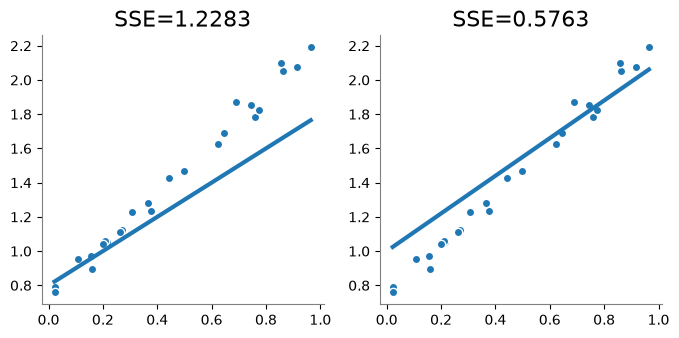

In [ ]:

def plot_forecast(w0, w1):

    # vector ordenado de valroes
    z_sample = np.linspace(min(x_sample), max(x_sample))

    #valores ajustados
    y_forecasts = w0 + w1 * z_sample

    #dispersión de los puntos reales.
    plt.scatter(x_sample, y_sample, color="tab:blue", edgecolors="white")

    #dispersión de los puntos ajustados.
    plt.plot(z_sample, y_forecasts, "-", color="tab:blue", linewidth=3)

    #título
    plt.title(
        "SSE=" + str(round(sse(w0, w1), 4)),
        fontsize=16,
    )

    plt.gca().spines["left"].set_color("gray")
    plt.gca().spines["bottom"].set_color("gray")
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)


plt.figure(figsize=(8, 3.5))

plt.subplot(1, 2, 1)
plot_forecast(w0=0.8, w1=1)

plt.subplot(1, 2, 2)
plot_forecast(w0=1.0, w1=1.1)

## Forma de la superficie de la función de pérdida
Ya que lafunción SSE() depende de w_0 y w_1, es posible ver gráficamente su forma: 

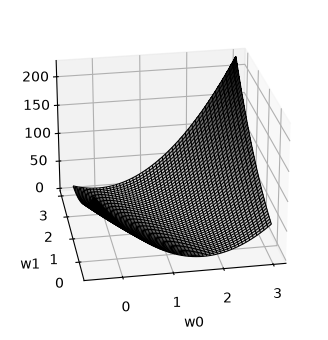

In [ ]:
def plot_surface():
    #valores de w0 y w1
    W0 = np.linspace(-0.5, 3.0, 50)
    W1 = np.linspace(-0.5, 3.0, 50)

    # organizción de los datos para evaluar una función de dos variables.
    W0, W1 = np.meshgrid(W0, W1)
    #evaluación 
    F = sse(W0, W1)

    #
    # Superficie de error
    #
    #tamaño de la figura y decir que es para un gráfico 3D, con una vista de azimut (angulo) y elevación específica.
    ax = plt.figure(figsize=(4, 4)).add_subplot(projection="3d", azim=-100, elev=25)
    #               X,  Y,  Z
    ax.plot_surface(W0, W1, F, cmap=cm.binary, linewidth=1, antialiased=False)
    ax.plot_wireframe(W0, W1, F, color="black", linewidth=0.8, alpha=1.0)

    plt.xlabel("w0")
    plt.ylabel("w1")


plot_surface()
plt.show()

# Es notable que es una función cuadrática pues es convexa y tiene un único mínimo global. 
# Esto es importante porque significa que podemos encontrar los valores óptimos de w0 y w1 
# que minimizan la función de pérdida utilizando métodos de optimización, como el descenso de gradiente.

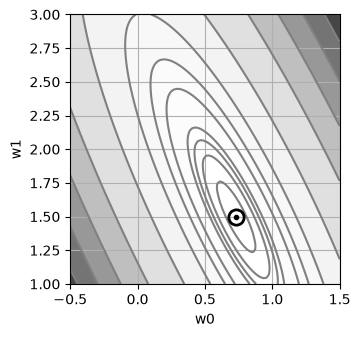

In [ ]:
# Contorno de la función de pérdida
def plot_contour():

    #Malla de puntos para intercepto y pendiente
    W0 = np.linspace(-0.5, 1.5, 100)
    W1 = np.linspace(1.0, 3.0, 100)
    W0, W1 = np.meshgrid(W0, W1)
    F = sse(W0, W1)

    #estabalecer niveles para el SSE
    levels = [0, 0.2, 0.5, 0.75, 1, 2, 3, 5, 10, 20, 30, 40, 50, 60]

    # creación de la figura y el eje, estableciendo la relación de aspecto como "igual" para que las unidades en ambos ejes sean iguales.
    _, ax = plt.subplots(figsize=(3.5, 3.5))
    ax.set_aspect("equal", "box")

    #creamos gráficos para gráficar la función de pérdida en un contorno de colores y líneas de contorno.
    ax.contourf(W0, W1, F, cmap=cm.Greys, levels=levels, alpha=0.8)
    ax.contour(W0, W1, F, colors="gray", levels=levels)

    #Punto de óptima.
    plt.plot(
        #se presenta el punto de mínimo global de la función de pérdida, que es el valor óptimo de w0 y w1 que minimiza la suma de errores al cuadrado (SSE).
        [0.731],
        [1.498],
        "o",
        color="black",
        fillstyle="none",
        markersize=11,
        markeredgewidth=2,
    )
    plt.plot([0.731], [1.498], ".", color="black")

    ax.set_xlabel("w0")
    ax.set_ylabel("w1")
    ax.grid()


plot_contour()

Entonces para aplicar el método del gradiente descendente primero hay que realizar los cálculos del vector gradiente.

La derivada respecto a w_0 es:

\begin{split} \frac{\partial}{\partial w_0} \text{SSE}(w_0, w_1) & = \frac{\partial}{\partial w_0} \sum_i (d_i - y_i)^2 \\ & = \frac{\partial}{\partial w_0} \sum_i (d_i - w_0 - w_1 x_i)^2 \\ & = \sum_i \frac{\partial}{\partial w_0} (d_i - w_0 - w_1 x_i)^2 \\ & = \sum_i 2 \times (d_i - w_0 - w_1 x_i) \times \frac{\partial}{\partial w_0} (d_i - w_0 - w_1 x_i) \\ & = \sum_i 2 \times e_i \times (-1) \\ & = -2 \sum_i e_i \\ \end{split}

La derivada respecto a w_1 es:

\begin{split} \frac{\partial}{\partial w_1} \text{SSE}(w_0, w_1) & = \frac{\partial}{\partial w_1} \sum_i (d_i - y_i)^2 \\ & = \frac{\partial}{\partial w_1} \sum_i (d_i - w_0 - w_1 x_i)^2 \\ & = \sum_i \frac{\partial}{\partial w_1} (d_i - w_0 - w_1 x_i)^2 \\ & = \sum_i 2 * (d_i - w_0 - w_1 x_i) \times \frac{\partial}{\partial w_1} (d_i - w_0 - w_1 x_i) \\ & = \sum_i 2 * e_i \times (-x_i) \\ & = -2 \sum_i e_i x_i \\ \end{split}

Si los parámetros w_0 y w_1 se agrupan en el vector de parámetros $\mathbf{w}=[w_0, w_1]'$, entonces:

$$\frac{\partial}{\partial \mathbf{w}} \text{SSE}(\mathbf{w}) = \left[ \begin{array}{c} -2 \sum_i e_i \\ -2 \sum_i e_i x_i \end{array} \right]$$

## Codificación del gradiente
$$\mathbf{w}_k = \mathbf{w}_{k-1} - \mu \frac{\partial}{\partial \mathbf{w}} \text{SSE}(\mathbf{w}_{k-1})$$

In [12]:
# cálcullo del gradiente de la función de pérdida con respecto a los parámetros w0 y w1.
def gradient(w0, w1):
    #valores ajustados
    y_forecasts = [w0 + w1 * x_value for x_value in x_sample]

    # residuales
    errors = [y_true - y_forecast for y_true, y_forecast in zip(y_sample, y_forecasts)]

    # se calcula el gradiente de la función de pérdida con respecto a los parámetros w0 y w1.
    gradient_w0 = -2 * sum(errors)
    gradient_w1 = -2 * sum(
        [error * x_value for error, x_value in zip(errors, x_sample)]
    )

    # se retorna el gradiente de la función de pérdida con respecto a los parámetros w0 y w1.
    return gradient_w0, gradient_w1

$$\mathbf{w}_k = \mathbf{w}_{k-1} - \mu \frac{\partial}{\partial \mathbf{w}} \text{SSE}(\mathbf{w}_{k-1})$$

In [13]:
def improve(w0, w1, mu):
    gradient_w0, gradient_w1 = gradient(w0, w1)

    w0 = w0 - mu * gradient_w0
    w1 = w1 - mu * gradient_w1

    return w0, w1

# Proceso iterativo
Para realizar la optimización numérica, se parte de unos pesos iniciales aleatorios.

 w0 = 0.7320
 w1 = 1.4982
SSE = 0.0506


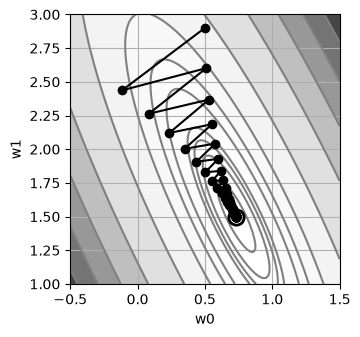

In [18]:
#
# Punto de inicio, valores arbitrarios de w0 y w1, y la tasa de aprendizaje mu.
#
w0 = 0.5
w1 = 2.9


history = {
    "w0": [w0], # historial de valores de w0 a lo largo de las iteraciones.
    "w1": [w1], # historial de valores de w1 a lo largo de las iteraciones.
    "sse": [sse(w0, w1)], # historial de valores de la suma de errores al cuadrado (SSE) a lo largo de las iteraciones.
}

mu = 0.03

# Iteración del proceso de optimización utilizando el método de descenso de gradiente para mejorar los valores de w0 y w1.
for epoch in range(100):
    w0, w1 = improve(w0, w1, mu)

    history["w0"].append(w0)
    history["w1"].append(w1)
    history["sse"].append(sse(w0, w1))


print(" w0 = {:6.4f}\n w1 = {:6.4f}\nSSE = {:6.4f}".format(w0, w1, sse(w0, w1)))

#hacer el gráfico de contorno. 
plot_contour()
plt.plot(history["w0"], history["w1"], marker="o", color="black")
plt.show()

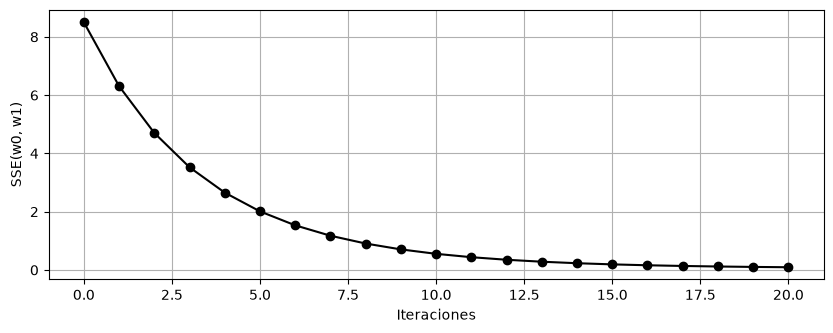

In [ ]:
# es notable el desenso del error a medida que aumentan las iteraciones
plt.figure(figsize=(10, 3.5))
plt.plot(history["sse"], "o-k")
plt.xlabel("Iteraciones")
plt.ylabel("SSE(w0, w1)")
plt.grid()

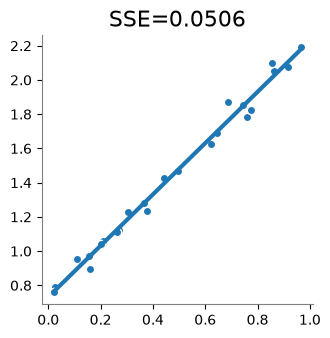

In [19]:
#
# A continuación se grafica la recta encontrada.
#
plt.figure(figsize=(3.5, 3.5))
plot_forecast(w0, w1)

Entonces, aprendizaje batch es el término que se refiere a que voy a calcular la corrección de los parámetros (elección de parámetros) por medio del método del gradiente descendente y se calcula sobre la totalidad de los datos. 